In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Create a mock fruit dataset
# Features: [Weight (grams), Color (1=Red, 2=Yellow, 3=Orange)]
# Target: 0=Apple, 1=Banana, 2=Orange

data = {
    'Weight': [150, 170, 140, 120, 130, 115, 180, 190, 175],
    'Color': [1, 1, 1, 2, 2, 2, 3, 3, 3],  # 1: Red, 2: Yellow, 3: Orange
    'Fruit': ['Apple', 'Apple', 'Apple', 'Banana', 'Banana', 'Banana', 'Orange', 'Orange', 'Orange']
}

df = pd.DataFrame(data)
print("Our Fruit Basket Data:")
display(df)

X = df[['Weight', 'Color']]
y = df['Fruit']

# Initialize a Random Forest with 5 individual decision trees (estimators)
rf_model = RandomForestClassifier(n_estimators=5, random_state=42)
rf_model.fit(X, y)

Our Fruit Basket Data:


,Weight,Color,Fruit
0,150,1,Apple
1,170,1,Apple
2,140,1,Apple
3,120,2,Banana
4,130,2,Banana
5,115,2,Banana
6,180,3,Orange
7,190,3,Orange
8,175,3,Orange


RandomForestClassifier(n_estimators=5, random_state=42)

In [2]:
# A new sample of fruit: Weight = 145g, Color = 1 (Red)
new_fruit = np.array([[145, 1]])

# Get overall ensemble prediction
overall_prediction = rf_model.predict(new_fruit)[0]

# Query each individual decision tree (estimator) for its vote
individual_votes = []
for i, tree in enumerate(rf_model.estimators_):
    vote = tree.predict(new_fruit)[0]
    # Map numerical class back to string label
    fruit_name = rf_model.classes_[int(vote)]
    individual_votes.append((f"Tree {i+1}", fruit_name))

votes_df = pd.DataFrame(individual_votes, columns=['Decision Tree', 'Voted Fruit'])
print("\n--- Votes from Individual Decision Trees ---")
display(votes_df)

print(f"\nFinal Ensemble Decision (Majority Vote): {overall_prediction}")


--- Votes from Individual Decision Trees ---


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Decision Tree,Voted Fruit
0,Tree 1,Apple
1,Tree 2,Apple
2,Tree 3,Apple
3,Tree 4,Apple
4,Tree 5,Banana



Final Ensemble Decision (Majority Vote): Apple


Model Accuracy on Training Data: 100.00%

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         3
      Banana       1.00      1.00      1.00         3
      Orange       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



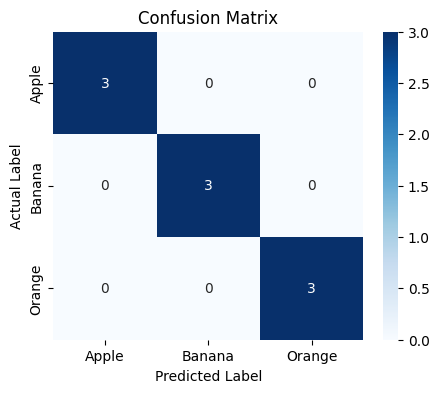

In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the training data
y_pred = rf_model.predict(X)

# Calculate metrics
accuracy = accuracy_score(y, y_pred)
print(f"Model Accuracy on Training Data: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Summary of Work
- **Goal**: Find which fruit is selected most often using a Random Forest.
- **Dataset**: Created a small sample of 9 fruits (Apples, Bananas, Oranges) categorized by weight and color.
- **Model**: Trained a Random Forest with 5 individual decision trees.
- **Testing**: Fed a new sample (145g, Red) to the model.
- **Voting**: Checked each individual tree's prediction. 4 trees voted for Apple, and 1 voted for Banana.
- **Result**: Majority voting selected **Apple** as the final prediction.